In [1]:
old_wd <- getwd()

setwd("../")

if (file.exists("renv/activate.R")) {
  source("renv/activate.R")
} else {
  stop("Could not find renv/activate.R in project root")
}

setwd(old_wd)

- The project is out-of-sync -- use `renv::status()` for details.


In [2]:
library(tidyverse)
library(reshape2)

# 1. Read the RDS file
eeg_data <- readRDS("../ds006018_functional/sub-001/task-auditoryoddball_Stimulus_S1.rds")

# Quick look at the structure
# Expected columns: Time, Cz, F3, F4, etc.
head(eeg_data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




$coefs
                [,1]
bspl4.1    8.4813896
bspl4.2  -12.2311617
bspl4.3    4.9392569
bspl4.4   -2.7026279
bspl4.5    0.6219896
bspl4.6   11.2758863
bspl4.7   71.4773666
bspl4.8    9.1838095
bspl4.9   14.0628797
bspl4.10 -16.0870526
bspl4.11  -4.9525214
bspl4.12 -11.2750964
bspl4.13 -17.6495273
bspl4.14 -21.7092669
bspl4.15  -4.2893822
bspl4.16 -11.4834304
bspl4.17   3.1123267
bspl4.18   2.4509995
bspl4.19   1.6225083
bspl4.20   6.7022322

$basis
$call
basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params, 
    dropind = dropind, quadvals = quadvals, values = values, 
    basisvalues = basisvalues)

$type
[1] "bspline"

$rangeval
[1] -0.2  0.8

$nbasis
[1] 20

$params
 [1] -0.14117647 -0.08235294 -0.02352941  0.03529412  0.09411765  0.15294118
 [7]  0.21176471  0.27058824  0.32941176  0.38823529  0.44705882  0.50588235
[13]  0.56470588  0.62352941  0.68235294  0.74117647

$dropind
NULL

$quadvals
NULL

$values
list()

$basisvalues
list()

$names
 [1] "bspl4.1"

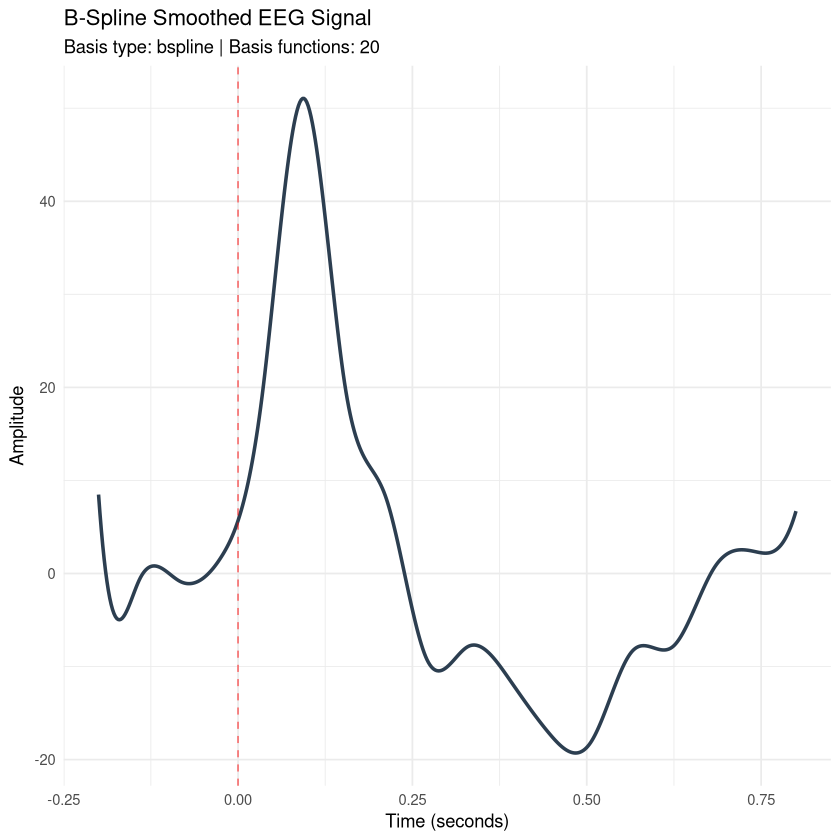

In [4]:
library(fda)
library(ggplot2)

# 2. Load your data
eeg_fd <- readRDS("../ds006018_functional/sub-001/task-auditoryoddball_Stimulus_S1.rds")

# 3. Evaluate the functional data object
# We create a sequence of time points based on the rangeval (-0.2 to 0.8)
time_points <- seq(eeg_fd$basis$rangeval[1], 
                   eeg_fd$basis$rangeval[2], 
                   length.out = 500)

# 'eval.fd' converts the spline coefficients into actual amplitude values
amplitude_values <- eval.fd(time_points, eeg_fd)

# 4. Create a data frame for plotting
plot_data <- data.frame(
  Time = time_points,
  Amplitude = as.vector(amplitude_values)
)

# 5. Visualize with ggplot2
ggplot(plot_data, aes(x = Time, y = Amplitude)) +
  geom_line(color = "#2c3e50", linewidth = 1) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", alpha = 0.5) +
  theme_minimal() +
  labs(
    title = "B-Spline Smoothed EEG Signal",
    subtitle = paste("Basis type:", eeg_fd$basis$type, "| Basis functions:", eeg_fd$basis$nbasis),
    x = "Time (seconds)",
    y = "Amplitude"
  )